In [5]:
import pandas as pd 
df = pd.read_csv('/Users/hallevidak/Downloads/airbnb_data.csv')
df

cols = df.columns
print(cols)

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')


/var/folders/27/lt6y3_rs5s35nrzxdb_j4k0m0000gn/T/ipykernel_55114/2437897189.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/hallevidak/Downloads/airbnb_data.csv')


In [6]:

for cols in df.columns:
    if pd.api.types.is_numeric_dtype(df[cols]):
        print (f"{cols} is Numeric")
        print (f'Nullish Values: {df[cols].isnull().sum()}')
        print (f'Mean: {df[cols].mean()}')
        print (f'Standard Deviation: {df[cols].std()}')
    else: 
        print (f"{cols} is Categroical")
        print (f'Nullish Values: {df[cols].isnull().sum()}')
        print (f'Unique Values: {df[cols].nunique()}')
        if df[cols].nunique() < 10:
                print (df[cols].unique())
        

id is Numeric
Nullish Values: 0
Mean: 29146234.522129845
Standard Deviation: 16257505.607308906
NAME is Categroical
Nullish Values: 250
Unique Values: 61281
host id is Numeric
Nullish Values: 0
Mean: 49254111474.32867
Standard Deviation: 28538996644.374817
host_identity_verified is Categroical
Nullish Values: 289
Unique Values: 2
['unconfirmed' 'verified' nan]
host name is Categroical
Nullish Values: 406
Unique Values: 13190
neighbourhood group is Categroical
Nullish Values: 29
Unique Values: 7
['Brooklyn' 'Manhattan' 'brookln' 'manhatan' 'Queens' nan 'Staten Island'
 'Bronx']
neighbourhood is Categroical
Nullish Values: 16
Unique Values: 224
lat is Numeric
Nullish Values: 8
Mean: 40.728093870371374
Standard Deviation: 0.05585651602743888
long is Numeric
Nullish Values: 8
Mean: -73.94964395581123
Standard Deviation: 0.04952126420255946
country is Categroical
Nullish Values: 532
Unique Values: 1
['United States' nan]
country code is Categroical
Nullish Values: 131
Unique Values: 1
['US'

In [7]:
for col in df.columns: 
    if pd.api.types.is_numeric_dtype(df[col]) == False:
        print(col)

NAME
host_identity_verified
host name
neighbourhood group
neighbourhood
country
country code
instant_bookable
cancellation_policy
room type
price
service fee
last review
house_rules
license


In [8]:
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(col)
  

NAME
host_identity_verified
host name
neighbourhood group
neighbourhood
country
country code
instant_bookable
cancellation_policy
room type
price
service fee
last review
house_rules
license


In [9]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as stats 

In [10]:
stats.skew(df['number of reviews'], nan_policy = 'omit')

np.float64(3.8393399827193573)

In [11]:
stats.kurtosis(df['number of reviews'], nan_policy='omit')

np.float64(25.02858164593076)

/var/folders/27/lt6y3_rs5s35nrzxdb_j4k0m0000gn/T/ipykernel_55114/3450225761.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/opt/anaconda3/envs/python-class/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


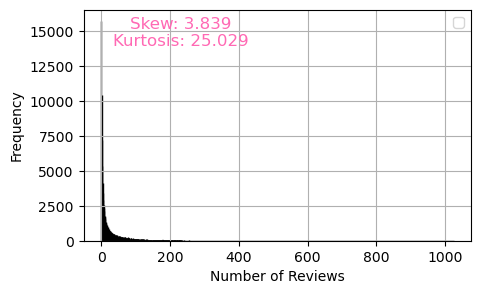

In [12]:
plt.figure(figsize=(5,3))
hts = df['number of reviews']
bins = hts.count()
plt.hist(x=hts, bins=bins, edgecolor='black', color='lightblue')
plt.xlabel ('Number of Reviews')
plt.ylabel ('Frequency')
plt.title = ("Histogram of Number of Reviews")

plt.grid(True)
kurt = stats.kurtosis(hts, nan_policy='omit')
sk = stats.skew(hts, nan_policy = 'omit')
text = f'Skew: {sk:.3f}\nKurtosis: {kurt:.3f}'
plt.text(
    x=0.25, 
    y=0.9, 
    s=text, 
    ha='center', 
    va='center', 
    fontsize=12, 
    color='hotpink',
    transform=plt.gca().transAxes) 

plt.legend()

plt.show()

In [13]:
num = df['number of reviews']

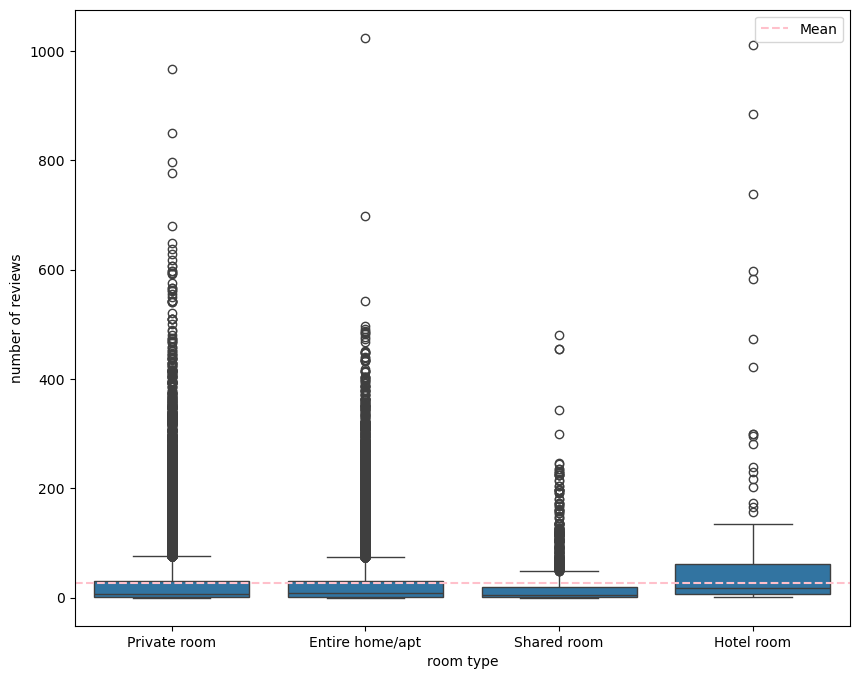

In [14]:
plt.figure(figsize=(10,8))
ht_boxes = sns.boxplot(data=df, x='room type', y='number of reviews')
plt.axhline (y=df['number of reviews'].mean(), color = 'pink', linestyle = '--', label = 'Mean')
plt.legend()

In [16]:
import pandas as pd
def multiplot(df:pd.DataFrame, col:str, xlabel:str):
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, height_ratios=[2,8])
    box = sns.boxplot(data=df, x='number of reviews', ax=ax1, color='lightpink')
    hist = sns.histplot(data=df, x='number of reviews', ax=ax2, color='teal', kde=True)

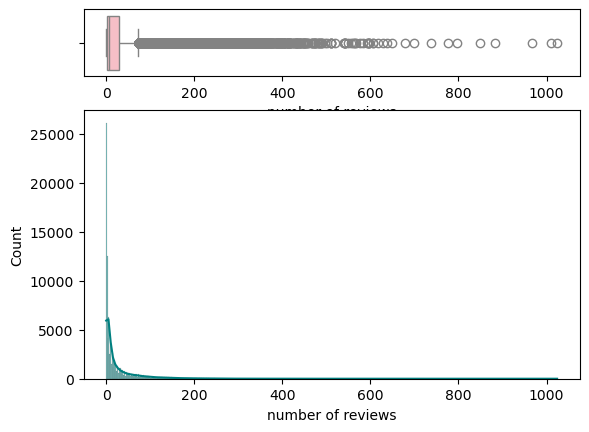

In [ ]:
import pandas as pd
def multiplot(df:pd.DataFrame, col:str, xlabel:str):
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, height_ratios=[2,8])
    box = sns.boxplot(data=df, x='number of reviews', ax=ax1, color='lightpink')
    hist = sns.histplot(data=df, x='number of reviews', ax=ax2, color='teal', kde=True)
    hist.set(xlabel=xlabel)

   
multiplot(df=df, col='frequency', xlabel='number of reviews')